In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

print("Path to dataset files:", path)

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Acer\.cache\kagglehub\datasets\rakeshrau\social-network-ads\versions\1


In [2]:
import pandas as pd
df = pd.read_csv(
    r"C:\Users\Acer\.cache\kagglehub\datasets\rakeshrau\social-network-ads\versions\1\Social_Network_Ads.csv"
)

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 
from tensorflow import keras 
from keras.layers import Dense 
from keras.models import Sequential 
from sklearn.preprocessing import Normalizer 
from sklearn.model_selection import train_test_split

In [5]:
df = df[['Age' , 'EstimatedSalary' , 'Purchased']]

In [7]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

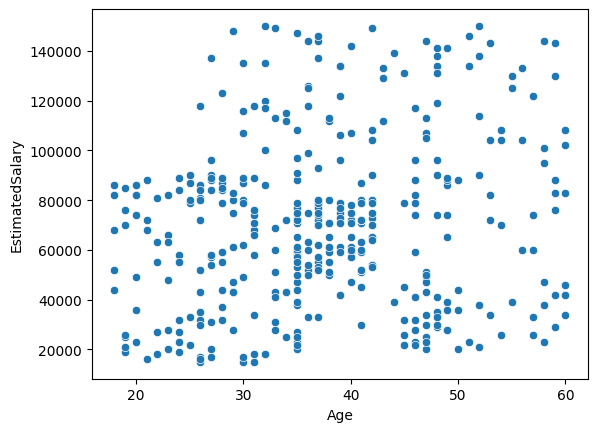

In [11]:
import seaborn as sns 
sns.scatterplot(x = df.iloc[: , 0] , y = df.iloc[: , 1] )

In [13]:
x = df.iloc[: , 0:2]
y = df.iloc[: , -1]

In [14]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [15]:
x.head()

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


In [16]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state= 42)

In [17]:
model = Sequential()

model.add(Dense(256 , activation= "relu" , input_dim = 2 ))
model.add(Dense(256 , activation= "relu"))
model.add(Dense(1 , activation= "sigmoid"))

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,817 (261.00 KB)

 Trainable params: 66,817 (261.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer= 'adam' , loss= 'binary_crossentropy' , metrics= ['accuracy'])

In [20]:
history = model.fit(x_train , y_train , validation_data= (x_test , y_test) , epochs= 100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5594 - loss: 1754.6414 - val_accuracy: 0.3500 - val_loss: 1061.6042
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4969 - loss: 1252.4746 - val_accuracy: 0.6500 - val_loss: 1297.0386
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 760.2265 - val_accuracy: 0.6500 - val_loss: 819.8584
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5031 - loss: 614.9991 - val_accuracy: 0.6500 - val_loss: 786.4562
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5094 - loss: 379.6013 - val_accuracy: 0.3500 - val_loss: 312.9148
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5344 - loss: 244.7171 - val_accuracy: 0.6500 - val_loss: 442.2729
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 358.5790 - val_accuracy: 0.3500 - val_loss: 646.7292
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5156 - l

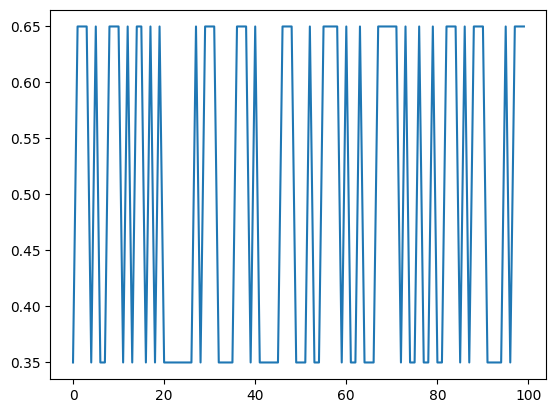

In [21]:
plt.plot(history.history['val_accuracy'])

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [27]:
model = Sequential()

model.add(Dense(256, activation= 'relu' , input_dim = 2))
model.add(Dense(256, activation= 'relu'))
model.add(Dense(1, activation= 'sigmoid'))

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(optimizer= 'adam' , loss= 'binary_crossentropy' , metrics= ['accuracy'])

In [29]:
history = model.fit(x_train_scaled , y_train , validation_data= (x_test_scaled , y_test) , epochs= 100)

Epoch 1/100


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8188 - loss: 0.5565 - val_accuracy: 0.8875 - val_loss: 0.3733
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8281 - loss: 0.3972 - val_accuracy: 0.9125 - val_loss: 0.2566
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8562 - loss: 0.3395 - val_accuracy: 0.9125 - val_loss: 0.2155
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8656 - loss: 0.3088 - val_accuracy: 0.9125 - val_loss: 0.1920
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8906 - loss: 0.2852 - val_accuracy: 0.9250 - val_loss: 0.1902
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9062 - loss: 0.2681 - val_accuracy: 0.9375 - val_loss: 0.1918
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9094 - loss: 0.2610 - val_accuracy: 0.9250 - val_loss: 0.1970
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9094 - loss: 0.2519 - val_accuracy: 0.9250 - val_loss: 0.

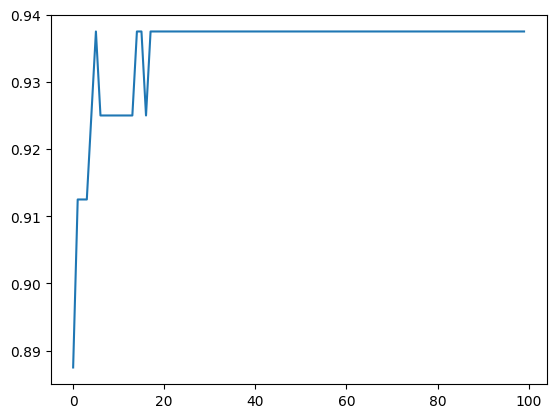

In [30]:
plt.plot(history.history['val_accuracy'])

<Axes: >

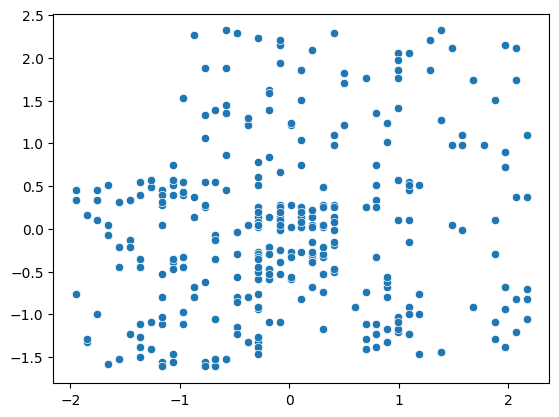

In [33]:
sns.scatterplot(x = x_train_scaled[: , 0] , y = x_train_scaled[: , 1])